In [69]:
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib import colors
from matplotlib.ticker import MultipleLocator
import os.path
from pathlib import Path
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from qbo1d import utils
from qbo1d import adsolver, adsolver_old
from qbo1d import emulate
from qbo1d.stochastic_2wave_forcing import WaveSpectrum

# %load_ext autoreload
# %autoreload 2


In [70]:
def ax_pos_inch_to_absolute(fig_size, ax_pos_inch):
    ax_pos_absolute = []
    ax_pos_absolute.append(ax_pos_inch[0]/fig_size[0])
    ax_pos_absolute.append(ax_pos_inch[1]/fig_size[1])
    ax_pos_absolute.append(ax_pos_inch[2]/fig_size[0])
    ax_pos_absolute.append(ax_pos_inch[3]/fig_size[1])
    
    return ax_pos_absolute

In [71]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')

Using cpu device


In [72]:
torch.set_default_dtype(torch.float64)

# An experiment on MLP

#### a) The MLP approach shows that the periods in different datasets, including deterministic forcing and stochastic 2wave forcing, are both shorter than the true numerical model. While the FNO can give the true period in deterministic forcing, but the shorter period in datasets with noise. 

#### b) The MLP can learn the boundary condition, but FNO cannnot. This experient is shown on google colab, where we test the fully-trained FNO model on two solvers (with boundary condition and without boundary condition). The MLP here is tested on the original solver, i.e. without boundary condition. The results show that this solver is enough for MLP, but cannot produce a stable solution for FNO. 

## Dataset based on model data

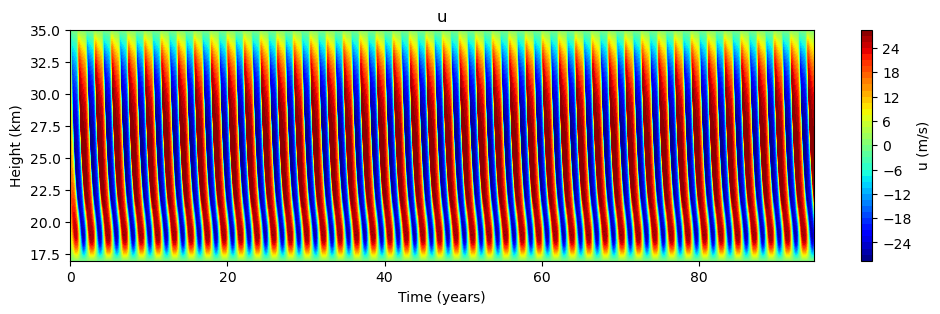

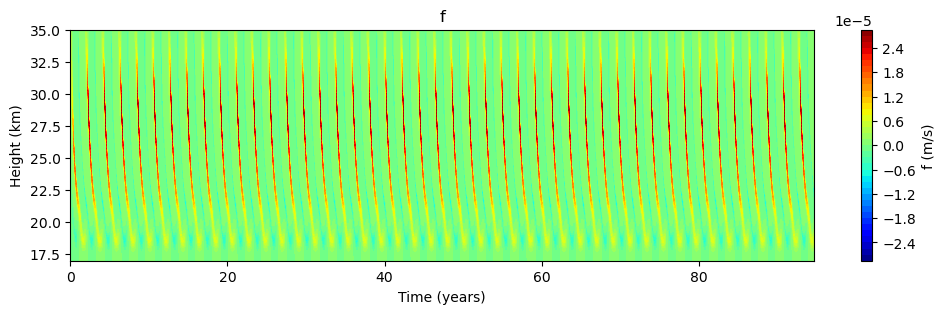

In [73]:
solver = adsolver.ADSolver(t_max=360*96*86400)
# gw = WaveSpectrum(solver)
# u = solver.solve(source_func=gw)
u, s = solver.solve()

f = s

# model = utils.load_model(solver)
# f = torch.zeros_like(u)
# for i in range(solver.time.shape[0]):
#     f[i, :] = model.forward(u[i, :])


time_in_years = np.arange(u.shape[0]) / 365.0
height_in_km = np.linspace(17, 35, u.shape[1])

plt.figure(figsize=(12, 3))
plt.contourf(time_in_years, height_in_km, u.T, cmap='jet', levels=50)
plt.colorbar(label='u (m/s)')
plt.xlabel('Time (years)')
plt.ylabel('Height (km)')
plt.title('u')
plt.show()

plt.figure(figsize=(12, 3))
plt.contourf(time_in_years, height_in_km, f.T, cmap='jet', levels=50)
plt.colorbar(label='f (m/s)')
plt.xlabel('Time (years)')
plt.ylabel('Height (km)')
plt.title('f')
plt.show()

In [74]:
class QBODataset(Dataset):
    def __init__(self, u, f, feature_transform=None, label_transform=None):

        self.features = torch.tensor(u)
        self.labels = torch.tensor(f)

        self.feature_transform = feature_transform
        self.label_transform = label_transform

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):

        feature = self.features[idx, :]
        label = self.labels[idx, :]

        if self.feature_transform:
            feature = self.feature_transform(feature)
        if self.label_transform:
            label = self.label_transform(label)

        return feature, label


data = QBODataset(u, f)

num_split = int((len(data))/2)

batch_size = 360

split_data = torch.utils.data.random_split(data, [num_split, len(data)-num_split], generator=torch.Generator().manual_seed(42))
train_dataloader = DataLoader(split_data[0], batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(split_data[1], batch_size=batch_size, shuffle=True)

C:\Users\xueya\AppData\Local\Temp\ipykernel_50180\2777622986.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.features = torch.tensor(u)
C:\Users\xueya\AppData\Local\Temp\ipykernel_50180\2777622986.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.labels = torch.tensor(f)


torch.Size([360, 73])


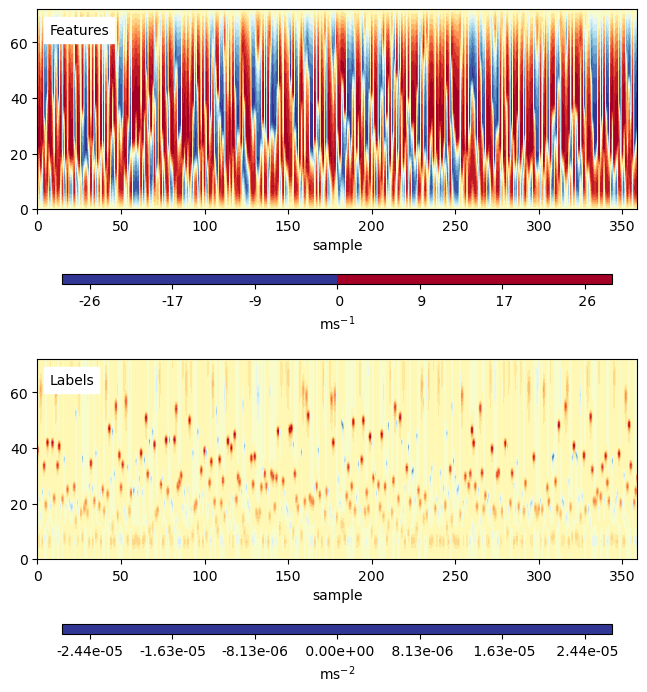

In [75]:
# plot training data
dataiter = iter(train_dataloader)
for i in range(47):
    features, labels = next(dataiter)

print(features.shape)

fig_size = (06.90, 02.20+01.50)
fig = plt.figure(figsize=fig_size)

ax = []

ax.append(fig.add_axes(ax_pos_inch_to_absolute(fig_size, [00.75, 04.75, 06.00, 02.00])))
ax.append(fig.add_axes(ax_pos_inch_to_absolute(fig_size, [00.75, 01.25, 06.00, 02.00])))

h = []

cmin = -features.abs().max()
cmax = features.abs().max()

h.append(ax[0].contourf(features.T, 21, cmap="RdYlBu_r", vmin=cmin, vmax=cmax))

ax[0].set_xlabel('sample', fontsize=10)

ax[0].text(07.00, 67, "Features", horizontalalignment='left', verticalalignment='top', color='black', backgroundcolor='white', fontsize=10)

# # colorbars
cbar_ax0 = fig.add_axes(ax_pos_inch_to_absolute(fig_size, [01.00, 04.00, 05.50, 00.10]))
ax[0].figure.colorbar(plt.cm.ScalarMappable(cmap="RdYlBu_r"), cax=cbar_ax0, format='% 2.0f',
                      boundaries=np.linspace(cmin, cmax, 21), orientation='horizontal',
                      label=r'$\mathrm{m s^{-1}}$')



cmin = -labels.abs().max()
cmax = labels.abs().max()

h.append(ax[1].contourf(labels.T, 21, cmap="RdYlBu_r", vmin=cmin, vmax=cmax))

ax[1].set_xlabel('sample', fontsize=10)

ax[1].text(07.00, 67, "Labels", horizontalalignment='left', verticalalignment='top', color='black', backgroundcolor='white', fontsize=10)


cbar_ax0 = fig.add_axes(ax_pos_inch_to_absolute(fig_size, [01.00, 00.50, 05.50, 00.10]))
ax[0].figure.colorbar(plt.cm.ScalarMappable(cmap="RdYlBu_r"), cax=cbar_ax0, format='% .2e',
                      boundaries=np.linspace(cmin, cmax, 21), orientation='horizontal',
                      label=r'$\mathrm{m s^{-2}}$')

## Setup model and optimizer

Hyperparameters were tuned by trial and error. I found that scaling the tendencies (labels) by their global absolute maximum works better than standardizing them (see results of emulation below). In addition, I found it unnecessary to scale the winds (features).

In [76]:
solver = adsolver_old.ADSolver(t_max=360*96*86400)

model = emulate.FullyConnected(solver)

learning_rate = 1e-2
epochs = 1000
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

scaler_Y = emulate.GlobalMaxScaler(data[:][1])
# scaler_Y = emulate.GlobalStandardScaler(data[:][1])

## Training

In order to properly emulate the tendencies, I found it necessary to drop the boundaries and train only on the interior. I was able to converge the error on the testing set to zero (i.e., "offline" testing), but the emulation ("online" testing) didn't work. During training, my network drops the boundaries of the input features and returns an output of size nlev-2. During emulation, when the self.training attribute of the model is set to False, the network adds zeros to the output boundaries so that it can be used by our code.

In [77]:
# training loop
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    avg_loss = 0
    for batch, (X, Y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, scaler_Y.transform(Y[:, 1:-1]))

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
   
        with torch.no_grad():
            avg_loss += loss.item()
            
    avg_loss /= len(dataloader)
    
    return avg_loss

# testing loop
def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    avg_loss = 0
    for batch, (X, Y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, scaler_Y.transform(Y[:, 1:-1]))
   
        with torch.no_grad():
            avg_loss += loss.item()
            
    avg_loss /= len(dataloader)
    
    return avg_loss

In [78]:
train_losses = []
test_losses = []
print(sum(p.numel() for p in model.parameters() if p.requires_grad))

2393978


In [ ]:
# training
for t in range(epochs):
    if t % 10 ==0:
        print(f"Epoch {t+1}\n-------------------------------")
    train_loss = train_loop(train_dataloader, model, emulate.relative_MSELoss, optimizer)
    train_losses.append(train_loss)
    test_loss = test_loop(test_dataloader, model, emulate.relative_MSELoss)
    test_losses.append(test_loss)
print("Done!")

Epoch 1
-------------------------------
Epoch 11
-------------------------------
Epoch 21
-------------------------------
Epoch 31
-------------------------------
Epoch 41
-------------------------------
Epoch 51
-------------------------------
Epoch 61
-------------------------------
Epoch 71
-------------------------------
Epoch 81
-------------------------------
Epoch 91
-------------------------------
Epoch 101
-------------------------------
Epoch 111
-------------------------------
Epoch 121
-------------------------------
Epoch 131
-------------------------------
Epoch 141
-------------------------------
Epoch 151
-------------------------------
Epoch 161
-------------------------------
Epoch 171
-------------------------------
Epoch 181
-------------------------------
Epoch 191
-------------------------------
Epoch 201
-------------------------------
Epoch 211
-------------------------------
Epoch 221
-------------------------------
Epoch 231
-------------------------------
Epo

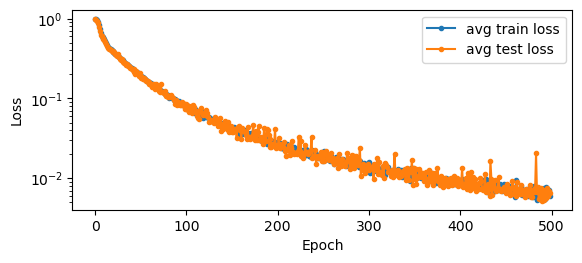

In [ ]:
fig_size = (06.00, 02.75)
fig = plt.figure(figsize=fig_size)

ax = []

ax.append(fig.add_axes(ax_pos_inch_to_absolute(fig_size, [00.60, 00.50, 05.00, 02.00])))

ax[0].plot(train_losses[1:], marker='.', color='C0', label="avg train loss")
ax[0].plot(test_losses[1:], marker='.', color='C1', label="avg test loss")
ax[0].set_yscale('log')
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

In [ ]:
# save model
torch.save(model.state_dict(), './models/fully_connected.pth')

## Emulate using the trained model ("online")

In [ ]:
torch.set_default_dtype(torch.float64)
solver = adsolver_old.ADSolver(t_max=360*10*86400)
model = utils.load_model(solver, ModelClass=emulate.FullyConnected, path_to_state_dict='./models/fully_connected.pth')
model.scaler_Y = scaler_Y
u = solver.solve(source_func=model)

solver = adsolver_old.ADSolver(t_max=360*10*86400)
u_model = solver.solve()

f_mm = torch.zeros_like(u_model)

with torch.no_grad():
  for i in range(u_model.shape[0]):
    Y = model(u_model[i,:])
    f_mm[i,:] = Y

f = torch.zeros_like(u)
with torch.no_grad():
  for i in range(u.shape[0]):
    Y = model(u[i,:])
    f[i,:] = Y


In [ ]:
nu_model = utils.load_model(solver)
f_true = torch.zeros_like(u_model)
for i in range(solver.time.shape[0]):
    f_true[i, :] = nu_model.forward(u_model[i, :])


In [ ]:
u = u.detach()

In [ ]:
np.savetxt('u_nonoise_nn.txt', u)
np.savetxt('f_nonoise_nn.txt', f)
np.savetxt('fmm_nonoise_nn.txt', f_mm)

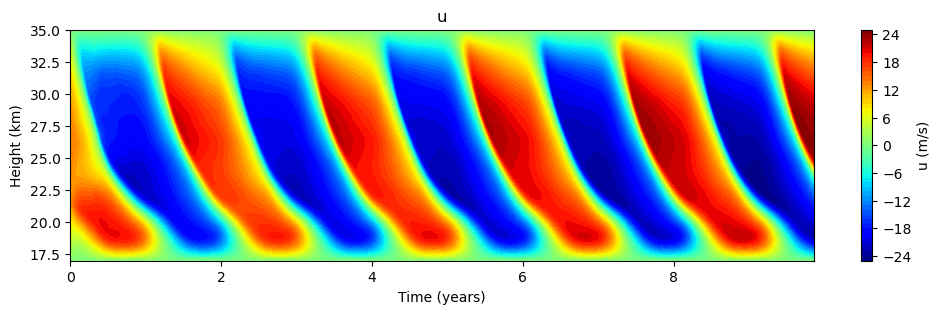

In [ ]:
time_in_years = np.arange(u.shape[0]) / 365.0
height_in_km = np.linspace(17, 35, u.shape[1])

plt.figure(figsize=(12, 3))
plt.contourf(time_in_years, height_in_km, u.T, cmap='jet', levels=50)
plt.colorbar(label='u (m/s)')
plt.xlabel('Time (years)')
plt.ylabel('Height (km)')
plt.title('u')
plt.show()

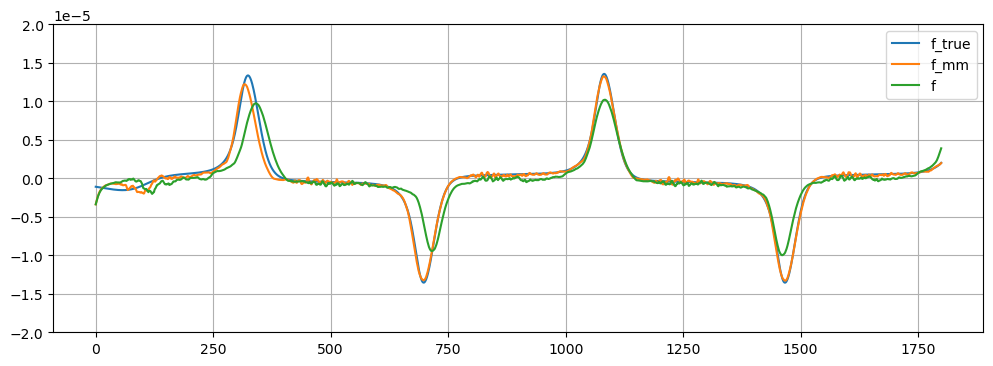

In [ ]:
height = 20
time_length = int(0.5*f.shape[0])

plt.figure(figsize=(12, 4))
plt.plot(f_true[:time_length,height], label='f_true')
plt.plot(f_mm[:time_length,height], label='f_mm')
plt.plot(f[:time_length,height], label='f')
plt.ylim([-2e-5, 2e-5])
plt.legend()
plt.grid()
plt.show()

Training set with noise

In [ ]:
solver = adsolver.ADSolver(t_max=360*96*86400)
gw = WaveSpectrum(solver)
u, f = solver.solve(source_func=gw)

data = QBODataset(u, f)

num_split = int((len(data))/2)

batch_size = 360

split_data = torch.utils.data.random_split(data, [num_split, len(data)-num_split], generator=torch.Generator().manual_seed(42))
train_dataloader = DataLoader(split_data[0], batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(split_data[1], batch_size=batch_size, shuffle=True)

C:\Users\xueya\AppData\Local\Temp\ipykernel_50180\2777622986.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.features = torch.tensor(u)
C:\Users\xueya\AppData\Local\Temp\ipykernel_50180\2777622986.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.labels = torch.tensor(f)


In [ ]:
solver = adsolver_old.ADSolver(t_max=360*96*86400)

model = emulate.FullyConnected(solver)

learning_rate = 1e-1
epochs = 100
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

scaler_Y = emulate.GlobalMaxScaler(data[:][1])

In [ ]:
train_losses = []
test_losses = []

In [ ]:
# training
for t in range(epochs):
    if t % 10 ==0:
        print(f"Epoch {t+1}\n-------------------------------")
    train_loss = train_loop(train_dataloader, model, emulate.relative_MSELoss, optimizer)
    train_losses.append(train_loss)
    test_loss = test_loop(test_dataloader, model, emulate.relative_MSELoss)
    test_losses.append(test_loss)
print("Done!")

Epoch 1
-------------------------------
Epoch 11
-------------------------------
Epoch 21
-------------------------------
Epoch 31
-------------------------------
Epoch 41
-------------------------------
Epoch 51
-------------------------------
Epoch 61
-------------------------------
Epoch 71
-------------------------------
Epoch 81
-------------------------------
Epoch 91
-------------------------------
Done!


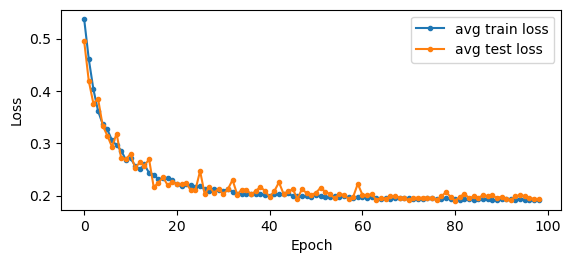

In [ ]:
fig_size = (06.00, 02.75)
fig = plt.figure(figsize=fig_size)

ax = []

ax.append(fig.add_axes(ax_pos_inch_to_absolute(fig_size, [00.60, 00.50, 05.00, 02.00])))

ax[0].plot(train_losses[1:], marker='.', color='C0', label="avg train loss")
ax[0].plot(test_losses[1:], marker='.', color='C1', label="avg test loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

In [ ]:
torch.save(model.state_dict(), './models/fully_connected_stochastic.pth')

In [ ]:
torch.set_default_dtype(torch.float64)
solver = adsolver_old.ADSolver(t_max=360*20*86400)
model = utils.load_model(solver, ModelClass=emulate.FullyConnected, path_to_state_dict='./models/fully_connected_stochastic.pth')
model.scaler_Y = scaler_Y
u = solver.solve(source_func=model)

solver = adsolver_old.ADSolver(t_max=360*20*86400)
gw = WaveSpectrum(solver)
u_model = solver.solve(source_func=gw)

f_mm = torch.zeros_like(u_model)

with torch.no_grad():
  for i in range(u_model.shape[0]):
    Y = model(u_model[i,:])
    f_mm[i,:] = Y

f = torch.zeros_like(u)
with torch.no_grad():
  for i in range(u.shape[0]):
    Y = model(u[i,:])
    f[i,:] = Y


In [ ]:
nu_model = utils.load_model(solver)
f_true = torch.zeros_like(u_model)
for i in range(solver.time.shape[0]):
    f_true[i, :] = nu_model.forward(u_model[i, :])

u = u.detach()

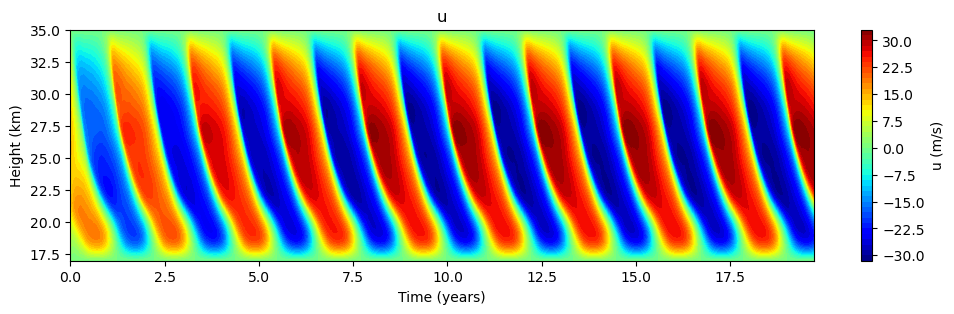

In [ ]:
time_in_years = np.arange(u.shape[0]) / 365.0
height_in_km = np.linspace(17, 35, u.shape[1])

plt.figure(figsize=(12, 3))
plt.contourf(time_in_years, height_in_km, u.T, cmap='jet', levels=50)
plt.colorbar(label='u (m/s)')
plt.xlabel('Time (years)')
plt.ylabel('Height (km)')
plt.title('u')
plt.show()

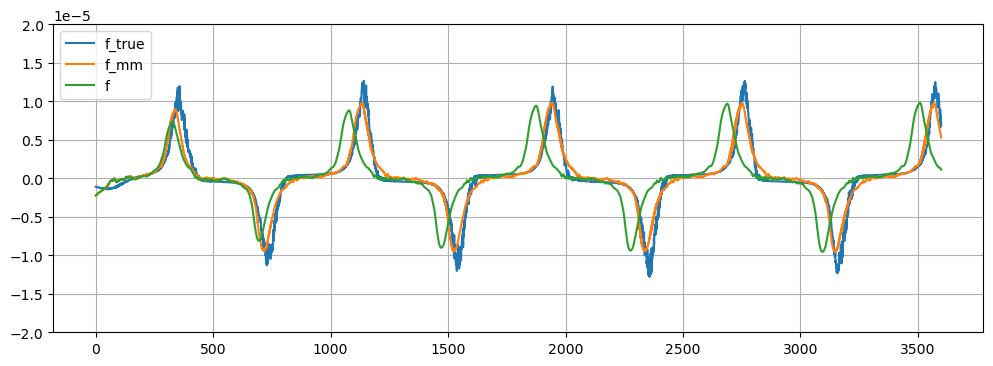

In [ ]:
height = 20
time_length = int(0.5*f.shape[0])

plt.figure(figsize=(12, 4))
plt.plot(f_true[:time_length,height], label='f_true')
plt.plot(f_mm[:time_length,height], label='f_mm')
plt.plot(f[:time_length,height], label='f')
plt.ylim([-2e-5, 2e-5])
plt.legend()
plt.grid()
plt.show()